# Deep learning model: Long Short Term Memory (LSTM)
### Implemented by: Junior Chaj Mejia

### Collect packages

In [31]:
from collections import Counter
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
import pandas as pd
import pandas as pd
import re
import torch
import torch.nn as nn

### Pre-process for LSTM

In [6]:
print("Loading dataset from HuggingFace...")
emotion_dataset = load_dataset("dair-ai/emotion")

train_data = pd.DataFrame(emotion_dataset["train"])
test_data  = pd.DataFrame(emotion_dataset["test"])
val_data   = pd.DataFrame(emotion_dataset["validation"])

print(f"Train: {len(train_data)} | Test: {len(test_data)} | Val: {len(val_data)}")

def clean_text_lstm(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"\b(not|no|never|n't)\s+(\w+)", r"\1_\2", text)
    text = re.sub(r"[^a-z!?_\s]", "", text)
    text = re.sub(r"!+", "!", text)
    text = re.sub(r"\?+", "?", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_data["cleaned_text"] = train_data["text"].apply(clean_text_lstm)
test_data["cleaned_text"]  = test_data["text"].apply(clean_text_lstm)
val_data["cleaned_text"]   = val_data["text"].apply(clean_text_lstm)

rows_before = len(train_data)
train_data = train_data.drop_duplicates(subset="text").reset_index(drop=True)
print(f"Duplicates removed from train: {rows_before - len(train_data)}")

train_df = train_data
val_df   = val_data
test_df  = test_data

Loading dataset from HuggingFace...
Train: 16000 | Test: 2000 | Val: 2000
Duplicates removed from train: 31


In [7]:
train_data["seq_len"] = train_data["cleaned_text"].apply(lambda x: len(x.split()))
print("\nSequence length stats (train):")
print(train_data["seq_len"].describe())

# Inspect samples
print(train_data["cleaned_text"].head(10))


Sequence length stats (train):
count    15969.000000
mean        19.015280
std         10.896035
min          1.000000
25%         11.000000
50%         17.000000
75%         25.000000
max         64.000000
Name: seq_len, dtype: float64
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
5    ive been feeling a little burdened lately wasn...
6    ive been taking or milligrams or times recomme...
7    i feel as confused about life as a teenager or...
8    i have been with petronas for years i feel tha...
9                                  i feel romantic too
Name: cleaned_text, dtype: str


### Functions for dataset

In [20]:
def build_vocab(texts, max_vocab_size=20000, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, freq in counter.most_common(max_vocab_size):
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(train_df['cleaned_text'])
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

MAX_LEN = 60

def encode(text, vocab, max_len=MAX_LEN):
    tokens = text.split()
    ids = [vocab.get(t, vocab['<UNK>']) for t in tokens][:max_len]
    ids += [vocab['<PAD>']] * (max_len - len(ids))
    return ids

Vocabulary size: 7598


### Configure Dataset

In [21]:
label_counts = Counter(train_df['label'])
num_classes  = 6
total        = sum(label_counts.values())
class_weights = torch.tensor(
    [total / (num_classes * label_counts[i]) for i in range(num_classes)],
    dtype=torch.float
)
print("Class weights:", class_weights.tolist())

class EmotionDataset(Dataset):
    def __init__(self, df, vocab, max_len=MAX_LEN):
        self.texts  = df['cleaned_text'].tolist()
        self.labels = df['label'].tolist()
        self.vocab  = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = torch.tensor(encode(self.texts[idx], self.vocab, self.max_len), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


Class weights: [0.5706475377082825, 0.49747663736343384, 2.0488836765289307, 1.2350348234176636, 1.3768752813339233, 4.685739517211914]


### LSTM Model

In [22]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                 num_classes=6, num_layers=2, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,   # ← reads text both ways
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc      = nn.Linear(hidden_dim * 2, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(x)
        # Concat final forward & backward hidden states from last layer
        out = torch.cat([hidden[-2], hidden[-1]], dim=1)
        out = self.dropout(out)
        return self.fc(out)

### Training configuration

In [23]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
print(f"Using device: {device}")

train_loader = DataLoader(EmotionDataset(train_df, vocab), batch_size=64, shuffle=True)
val_loader   = DataLoader(EmotionDataset(val_df,   vocab), batch_size=64)
test_loader  = DataLoader(EmotionDataset(test_df,  vocab), batch_size=64)

model     = LSTMClassifier(vocab_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))  # weighted loss

# Reduce LR when val F1 plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2,
)

Using device: mps


### Evaluation configuration

In [24]:
def evaluate(loader):
    model.eval()
    preds, labels_all = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().numpy())
            labels_all.extend(y.cpu().numpy())
    return {
        'accuracy':         accuracy_score(labels_all, preds),
        'precision_macro':  precision_score(labels_all, preds, average='macro', zero_division=0),
        'recall_macro':     recall_score(labels_all, preds, average='macro', zero_division=0),
        'f1_macro':         f1_score(labels_all, preds, average='macro', zero_division=0),
    }

def fmt(m):
    return (f"Acc={m['accuracy']:.4f}  Prec={m['precision_macro']:.4f}  "
            f"Rec={m['recall_macro']:.4f}  F1={m['f1_macro']:.4f}")

### Training loop

In [25]:
epochs      = 20
best_val_f1 = 0.0
patience    = 4
no_improve  = 0
best_path   = "best_lstm.pt"
history     = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}

for epoch in range(epochs):
    model.train()
    total_loss = 0
    train_preds, train_labels = [], []

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(y.cpu().numpy())

    train_acc   = accuracy_score(train_labels, train_preds)
    val_metrics = evaluate(val_loader)
    avg_loss    = total_loss / len(train_loader)
    val_f1      = val_metrics['f1_macro']

    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f} | Val: {fmt(val_metrics)}")

    history['train_loss'].append(avg_loss)           
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1'].append(val_metrics['f1_macro'])

    scheduler.step(val_f1)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"  LR: {current_lr:.2e}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        no_improve  = 0
        torch.save(model.state_dict(), best_path)
        print(f"   New best val F1: {best_val_f1:.4f} — checkpoint saved")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

Epoch 01 | Loss: 1.7762 | Train Acc: 0.1693 | Val: Acc=0.1260  Prec=0.1936  Rec=0.2493  F1=0.1092
  LR: 3.00e-04
   New best val F1: 0.1092 — checkpoint saved
Epoch 02 | Loss: 1.6675 | Train Acc: 0.2252 | Val: Acc=0.3315  Prec=0.3564  Rec=0.4014  F1=0.3375
  LR: 3.00e-04
   New best val F1: 0.3375 — checkpoint saved
Epoch 03 | Loss: 1.4889 | Train Acc: 0.3116 | Val: Acc=0.4200  Prec=0.4668  Rec=0.5410  F1=0.4616
  LR: 3.00e-04
   New best val F1: 0.4616 — checkpoint saved
Epoch 04 | Loss: 1.2913 | Train Acc: 0.4122 | Val: Acc=0.5165  Prec=0.5871  Rec=0.6410  F1=0.5698
  LR: 3.00e-04
   New best val F1: 0.5698 — checkpoint saved
Epoch 05 | Loss: 1.0981 | Train Acc: 0.5002 | Val: Acc=0.6295  Prec=0.6257  Rec=0.7026  F1=0.6488
  LR: 3.00e-04
   New best val F1: 0.6488 — checkpoint saved
Epoch 06 | Loss: 0.9385 | Train Acc: 0.5766 | Val: Acc=0.6615  Prec=0.6965  Rec=0.7308  F1=0.6849
  LR: 3.00e-04
   New best val F1: 0.6849 — checkpoint saved
Epoch 07 | Loss: 0.7925 | Train Acc: 0.6376 | 

### Evaluation on testing

In [26]:
print("\nLoading best checkpoint for test evaluation...")
model.load_state_dict(torch.load(best_path))

test_metrics = evaluate(test_loader)
print(f"\nTest results: {fmt(test_metrics)}")


Loading best checkpoint for test evaluation...

Test results: Acc=0.8985  Prec=0.8457  Rec=0.8960  F1=0.8651


### View sample predictions

In [27]:
LABEL_NAMES = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

def show_samples(loader, df, n=5):
    model.eval()
    all_preds, all_labels, all_texts = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = torch.argmax(model(x), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    # Uncleaned for readability
    all_texts = df['text'].tolist()  

    results = pd.DataFrame({
        'text':      all_texts[:len(all_preds)],
        'actual':    [LABEL_NAMES[l] for l in all_labels],
        'predicted': [LABEL_NAMES[p] for p in all_preds],
    })
    results['correct'] = results['actual'] == results['predicted']

    print("=" * 70)
    print(f"CORRECTLY CLASSIFIED (n={n})")
    print("=" * 70)
    correct = results[results['correct']].sample(n=n, random_state=42)
    for _, row in correct.iterrows():
        print(f"  [{row['actual']}]  {row['text']}")

    print()
    print("=" * 70)
    print(f"MISCLASSIFIED (n={n})")
    print("=" * 70)
    wrong = results[~results['correct']].sample(n=n, random_state=42)
    for _, row in wrong.iterrows():
        print(f"  actual={row['actual']}  predicted={row['predicted']}")
        print(f"  {row['text']}")
        print()

show_samples(test_loader, test_df, n=5)

CORRECTLY CLASSIFIED (n=5)
  [joy]  i feel any better
  [joy]  i feel privileged to be a part of something so eternal and so precious to the lord jesus he shed his blood so that churches like this could exist
  [sadness]  i told him that i was willing to do whatever it took for me to not have to feel this horrible every day
  [joy]  i hostage negotiator on her case has her feeling hopeful about her future
  [sadness]  i wasnt very interested in it but it evoked the feeling of an earth grittily doomed by aliens quite well

MISCLASSIFIED (n=5)
  actual=anger  predicted=surprise
  i was quite surprised with the weather these past few days but im so thankful for that since i still can wear my shorts out without feeling that cold yes no kidding

  actual=fear  predicted=anger
  i feel agitated with myself that i did not foresee her frustrations earlier leading to the ending of our relationship

  actual=anger  predicted=sadness
  i know their feelings are very real and not petty but neither

### Plot training curves

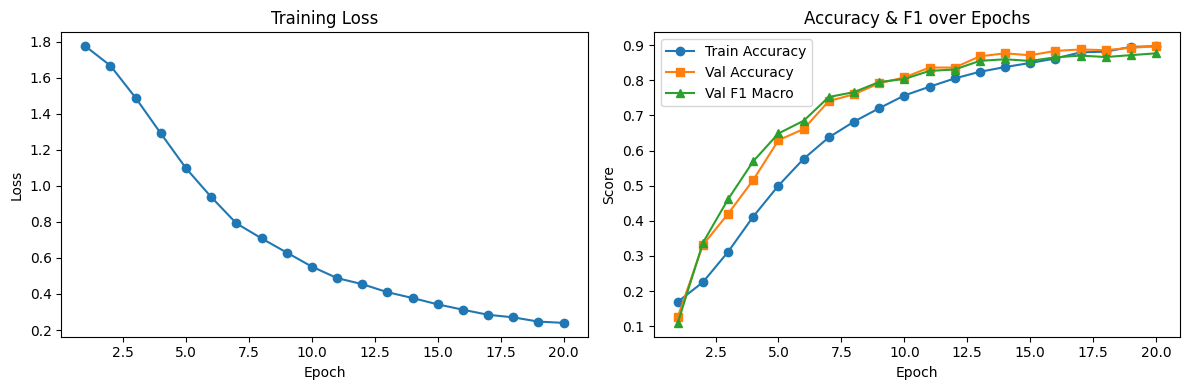

In [28]:
import matplotlib.pyplot as plt

epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_ran, history['train_loss'], marker='o')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(epochs_ran, history['train_acc'], marker='o', label='Train Accuracy')
axes[1].plot(epochs_ran, history['val_acc'],   marker='s', label='Val Accuracy')
axes[1].plot(epochs_ran, history['val_f1'],    marker='^', label='Val F1 Macro')
axes[1].set_title('Accuracy & F1 over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

### Generate classification report

In [ ]:
def get_predictions(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = torch.argmax(model(x), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return all_labels, all_preds

labels, preds = get_predictions(test_loader)
print(classification_report(labels, preds, target_names=list(LABEL_NAMES.values())))

              precision    recall  f1-score   support

     sadness       0.96      0.91      0.94       581
         joy       0.94      0.89      0.91       695
        love       0.71      0.92      0.80       159
       anger       0.88      0.95      0.91       275
        fear       0.93      0.83      0.88       224
    surprise       0.66      0.88      0.75        66

    accuracy                           0.90      2000
   macro avg       0.85      0.90      0.87      2000
weighted avg       0.91      0.90      0.90      2000

